The Breast Cancer Wisconsin dataset contains features derived from digitized images of fine‑needle aspirate (FNA) of breast masses. Each variable describes characteristics of cell nuclei present in the image. Here’s a brief of the variables you listed:

Mean radius → Average distance from the center to the perimeter of the nucleus.

Mean texture → Standard deviation of gray‑scale values (smoothness vs roughness of the nucleus surface).

Mean perimeter → Average length of the nucleus boundary.

Mean area → Average size of the nucleus.

Mean smoothness → Variation in radius lengths; lower values = smoother edges.

Mean compactness → Perimeter² / area − 1; measures how compact the nucleus is.

Mean concavity → Severity of concave portions of the contour.

Mean concave points → Number of concave portions in the contour.

Mean symmetry → Symmetry of the nucleus shape.

Mean fractal dimension → “Coastline approximation” of the contour; complexity of the boundary.

The dataset also includes worst values (e.g., worst radius, worst texture, worst perimeter, etc.), which represent the largest (or most extreme) value observed among all nuclei in the image. These capture the most abnormal cell characteristics.

👉 In total, there are 30 numeric features (mean, standard error, and worst values for each measurement). The target variable is binary:

0 = malignant (cancerous)

1 = benign (non‑cancerous)

This combination of geometric and textural features makes the dataset ideal for classification tasks like SVM, because the variables capture subtle differences between malignant and benign cell structures.

In [3]:
%pip install pandas 
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


  Using cached pandas-3.0.6-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.5-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.6-cp312-cp312-win_amd64.whl (9.7 MB)
Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl (12.6 MB)
Using cached tzdata-2026.5-py2.py3-none-any.whl (347 kB)

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------

In [5]:
from sklearn.datasets import load_breast_cancer

In [8]:
data = load_breast_cancer()

In [10]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [11]:
df = pd.DataFrame(data.data, columns=data.feature_names)

In [12]:
df.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
df['target'] = data.target

In [17]:
df.tail(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
559,11.51,23.93,74.52,403.5,0.09261,0.10210,0.11120,0.04105,0.1388,0.06570,...,37.16,82.28,474.2,0.12980,0.25170,0.3630,0.09653,0.2112,0.08732,1
560,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,0.1537,0.06171,...,33.17,100.20,706.7,0.12410,0.22640,0.1326,0.10480,0.2250,0.08321,1
561,11.20,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.00000,0.1060,0.05502,...,38.30,75.19,439.6,0.09267,0.05494,0.0000,0.00000,0.1566,0.05905,1
562,15.22,30.62,103.40,716.9,0.10480,0.20870,0.25500,0.09429,0.2128,0.07152,...,42.79,128.70,915.0,0.14170,0.79170,1.1700,0.23560,0.4089,0.14090,0
563,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.14740,0.2149,0.06879,...,29.41,179.10,1819.0,0.14070,0.41860,0.6599,0.25420,0.2929,0.09873,0
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.22160,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.16280,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.14180,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.26500,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.00000,0.2871,0.07039,1


**Exploratory Data Analysis**

In [18]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [22]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

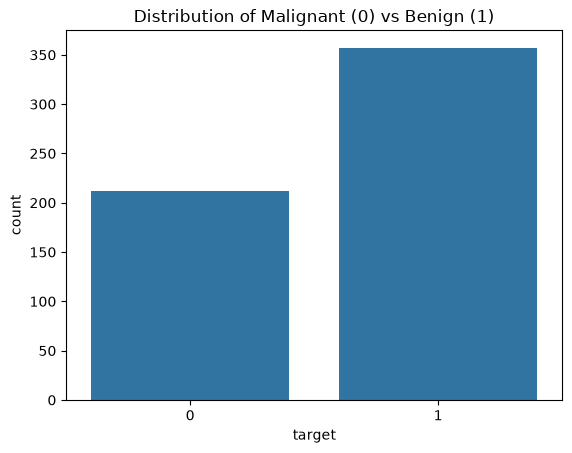

In [23]:
sns.countplot(x = "target", data = df)
plt.title("Distribution of Malignant (0) vs Benign (1)")
plt.show()

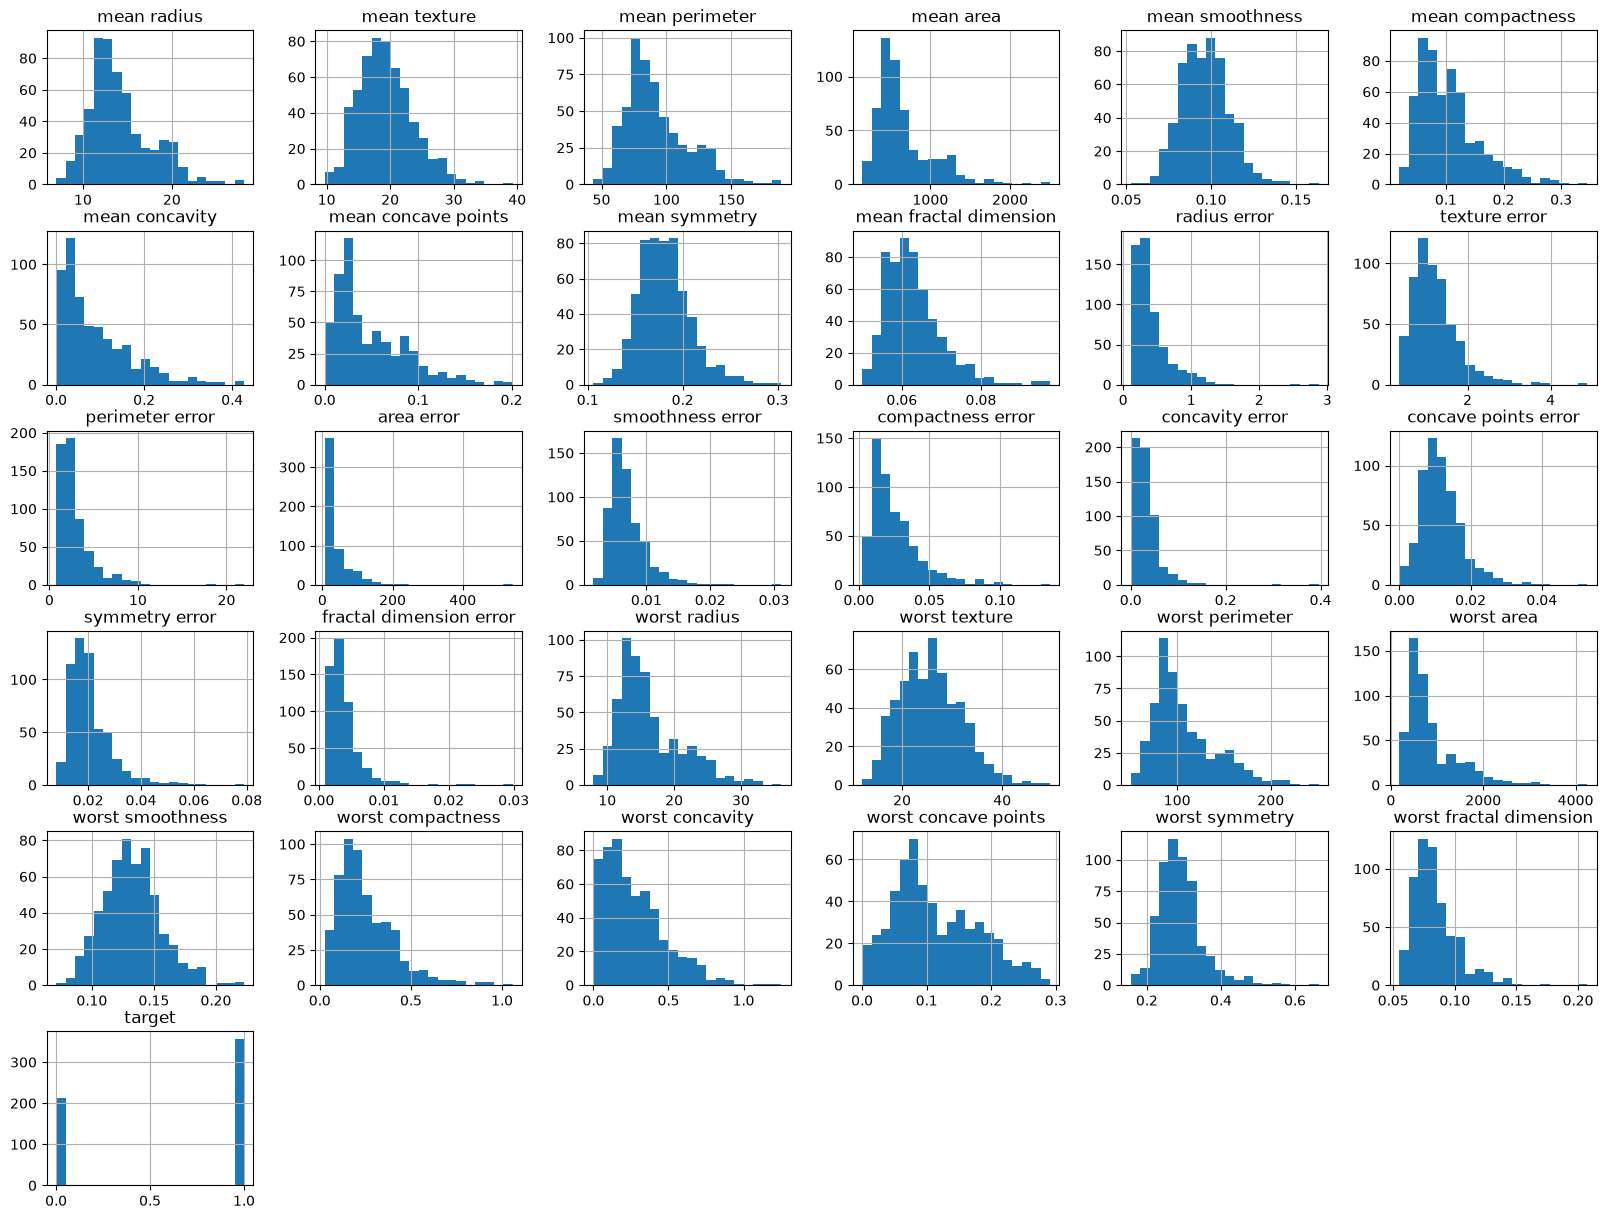

In [25]:
df.hist(bins = 20, figsize=(20,15))
plt.title("Feature Distribution")
plt.show()

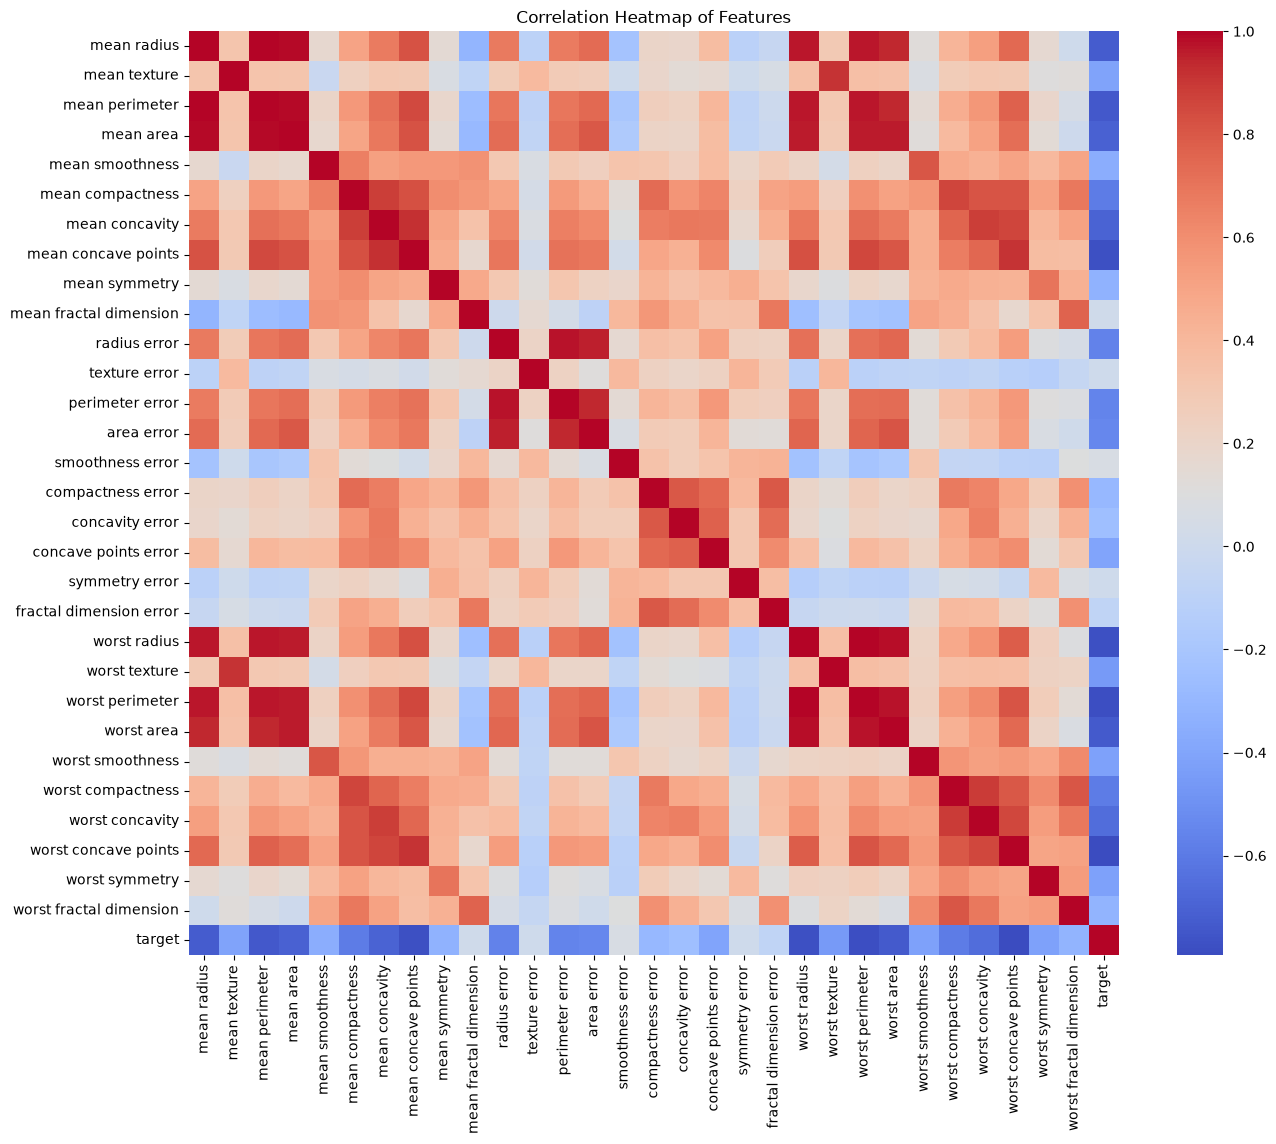

In [26]:
plt.figure(figsize=(15,12))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Features")
plt.show()


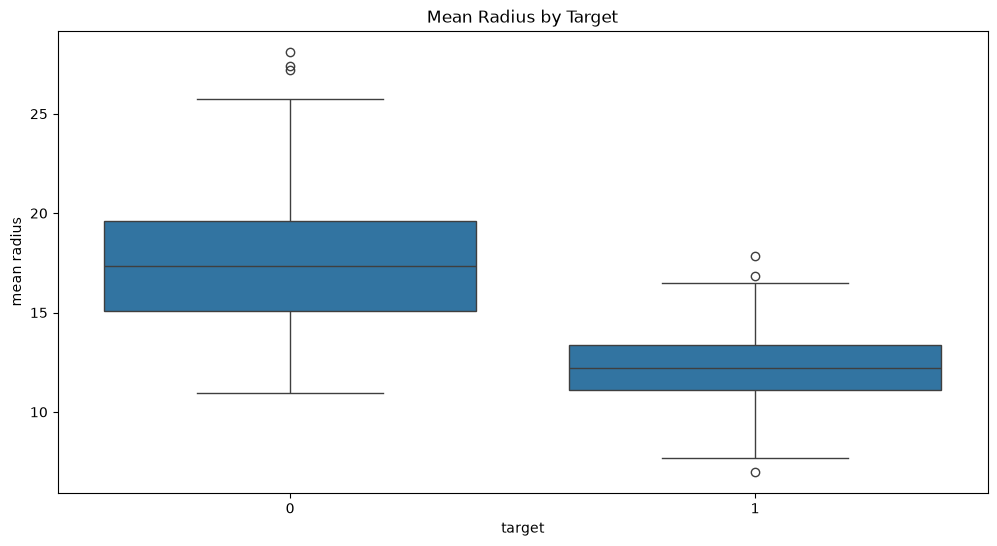

In [27]:
plt.figure(figsize=(12,6))
sns.boxplot(x='target', y='mean radius', data=df)
plt.title("Mean Radius by Target")
plt.show()


In [ ]:
X = df.drop(columns = "target") #independent variable
y=df.target #target variable

Train and Test Data

In [38]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

In [40]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [44]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [50]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = data.feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns = data.feature_names)

In [51]:
X_test_scaled_df.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.441809,-0.221639,-0.420045,-0.482548,0.160796,-0.016992,-0.124485,-0.286991,0.327691,0.094225,-0.040822,-0.328930,-0.194242,-0.259318,-0.021255,-0.375795,-0.132338,-0.187083,-0.354034,-0.082838,-0.256006,-0.223890,-0.315504,-0.352839,0.396158,-0.162669,-0.058250,-0.213360,0.118653,0.135392
1,1.409862,0.383034,1.328779,1.452397,-0.489952,-0.068514,0.208627,0.715347,-0.874240,-1.289050,1.567995,-0.727094,1.476295,1.546860,-0.941654,-0.522110,-0.274113,0.367084,-0.803689,-0.799412,1.758255,0.078415,1.692996,1.745945,-0.647669,-0.186625,-0.051437,0.895536,-0.645282,-0.988358
2,0.413909,-0.025288,0.427832,0.314598,0.810864,0.276148,0.668667,0.748354,0.348716,-0.780940,0.279548,-0.745831,0.139418,0.235623,-0.282811,-0.617017,-0.095582,-0.093890,-0.791198,-0.509822,0.617723,-0.011965,0.514063,0.491727,0.933752,-0.153543,0.418666,0.501548,-0.173391,-0.244738
3,-0.461842,-0.426915,-0.404412,-0.524644,0.552198,0.441372,-0.155948,-0.535027,-0.071784,1.199935,-0.939662,0.343022,-0.357998,-0.667466,1.096503,0.406057,0.576536,0.029258,0.105840,0.835273,-0.681669,-0.493471,-0.500683,-0.639190,0.503677,-0.019502,-0.172369,-0.611645,-0.637033,0.452081
4,-0.707968,-1.149845,-0.684981,-0.718407,0.173730,0.093157,-0.275606,-0.584779,-0.047255,0.714575,-0.523016,0.840524,-0.679921,-0.518325,1.885206,0.867599,0.803638,0.573440,-0.288175,0.648159,-0.807942,-0.996793,-0.812094,-0.741647,0.033283,-0.310969,-0.430414,-0.676402,-1.011575,-0.184936


**Training the Model**

In [52]:
from sklearn.svm import SVC

In [53]:
# Initialize svm
svm_model = SVC(kernel = "rbf", C = 1, gamma = "scale", random_state = 42)

In [54]:
svm_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [55]:
y_pred = svm_model.predict(X_test_scaled)

**Evaluating the model**

In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [57]:
print("Accuracy:",accuracy_score(y_test, y_pred))
print("\n Confusion metrix:\n",confusion_matrix(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9824561403508771

 Confusion metrix:
 [[ 61   2]
 [  1 107]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98        63
           1       0.98      0.99      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171

